# Compare SNOWPACK Runs — Lizum

Compare the **local SNOWPACK run** (`AXLIZ-AWS.smet`) against the **Alpsolut run** for the Lizum station.  
Variables: SWE · HS_mod · bulk density (ρ = SWE / HS).

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- global style -----------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.spines.left":    True,
    "axes.spines.bottom":  True,
    "axes.edgecolor":      "#D1D5DB",
    "axes.labelcolor":     "#374151",
    "axes.titlesize":      10,
    "axes.labelsize":      9,
    "xtick.color":         "#6B7280",
    "ytick.color":         "#6B7280",
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "grid.color":          "#E5E7EB",
    "grid.linewidth":      0.8,
    "legend.frameon":      False,
    "legend.fontsize":     8,
    "font.family":         "sans-serif",
})


import sys
sys.path.insert(0, "/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master")
from main import SnowToSwe

sts = SnowToSwe()

# --- prep: no NaNs, must start and end at 0 ---
import numpy as np

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


## 1. SMET Reader

In [59]:
def read_smet(filepath: str) -> pd.DataFrame:
    """Read a SMET 1.1 ASCII file and return a pandas DataFrame."""
    fields, nodata, data_start, rows = None, -999.0, False, []

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("fields"):
                fields = line.split("=", 1)[1].strip().split()
            elif line.startswith("nodata"):
                nodata = float(line.split("=", 1)[1].strip())
            elif line == "[DATA]":
                data_start = True
            elif data_start and line and not line.startswith("["):
                rows.append(line.split())

    df = pd.DataFrame(rows, columns=fields)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col])
    df.replace(nodata, pd.NA, inplace=True)
    df.set_index("timestamp", inplace=True)
    return df

## 2. Load Data

In [60]:
LOCAL_SMET = "/Users/jakobwerkgarner/code/mt_dsnow/compare_snowpack_runs/local_run_data/AXLIZ-AWS.smet"
ALP_SMET   = "/Users/jakobwerkgarner/code/mt_dsnow/compare_snowpack_runs/alpsolut_data/smet_45_2023-09-30T22_00_00.000Z_2026-05-31T22_00_00.000Z_1776958874979.smet"
df_local = read_smet(LOCAL_SMET)
df_alp   = read_smet(ALP_SMET)

print(f"Local   : {df_local.index[0]}  →  {df_local.index[-1]}  ({len(df_local):,} rows, {len(df_local.columns)} cols)")
print(f"Alpsolut: {df_alp.index[0]}  →  {df_alp.index[-1]}  ({len(df_alp):,} rows, {len(df_alp.columns)} cols)")

Local   : 2023-10-01 06:00:00  →  2024-06-01 00:00:00  (5,851 rows, 54 cols)
Alpsolut: 2023-10-01 02:00:00  →  2026-04-23 15:00:00  (19,880 rows, 75 cols)


## 2.1  Run dSnow out of couriosity

In [61]:
hs_m = (df_local['HS_meas'].resample("D").mean().clip(lower=0)/100) .tolist()
hs_m[0]  = 0.0
hs_m[-1] = 0.0


res = sts.convert_list(hs_m, timestep=24, verbose=False)

dsnow = pd.DataFrame()
dsnow['HS_meas'] = df_local['HS_meas'].resample("D").mean().clip(lower=0)
dsnow['SWE'] = pd.Series(res, index = dsnow.index)
dsnow


,HS_meas,SWE
timestamp,,
2023-10-01,4.905556,0.000000
2023-10-02,4.862500,3.948067
2023-10-03,5.166667,3.948067
2023-10-04,6.145833,3.948067
2023-10-05,5.583333,3.948067
...,...,...
2024-05-28,6.250000,21.667975
2024-05-29,5.366667,21.534222
2024-05-30,5.775000,21.534222


## 3. Build Comparison DataFrame

Daily means aligned to the local-run period.  
`HS_local` is converted from **cm → m** to match the Alpsolut convention.

In [62]:
start = df_local.index[0]
end   = df_local.index[-1]

check_df = pd.DataFrame(index=pd.date_range(start.date(), end.date(), freq="D"))

check_df["SWE_loc"] = df_local["SWE"].resample("D").mean()
check_df["SWE_alp"] = df_alp["SWE"].loc[start:end].resample("D").mean()

# df_local HS_mod is in cm; df_alp in m — normalise both to metres
check_df["HS_loc"]  = df_local["HS_mod"].resample("D").mean() / 100
check_df["HS_alp"]  = df_alp["HS_mod"].loc[start:end].resample("D").mean()

check_df["rho_loc"] = check_df["SWE_loc"] / check_df["HS_loc"]
check_df["rho_alp"] = check_df["SWE_alp"] / check_df["HS_alp"]

check_df['SWE_dsnow'] =dsnow ['SWE']
check_df['HS_meas'] = dsnow['HS_meas'] /100
check_df["rho_dsnow"] = check_df["SWE_dsnow"] / check_df["HS_meas"]

check_df.describe().round(2)

,SWE_loc,SWE_alp,HS_loc,HS_alp,rho_loc,rho_alp,SWE_dsnow,HS_meas,rho_dsnow
count,245.00,245.00,245.00,245.00,228.00,226.00,245.00,245.00,245.00
mean,303.50,295.59,0.91,0.79,316.56,346.43,229.02,0.80,254.83
std,174.73,195.73,0.47,0.48,73.97,96.74,153.81,0.47,102.54
min,0.00,0.00,0.00,0.00,125.58,106.28,0.00,0.05,0.00
25%,156.69,87.98,0.57,0.28,284.08,296.90,59.61,0.29,190.65
50%,331.65,325.05,1.09,0.90,318.56,364.39,254.97,0.90,268.05
75%,469.47,465.54,1.29,1.16,361.27,404.57,370.23,1.16,317.00
max,539.04,592.55,1.58,1.58,464.79,501.61,441.73,1.59,401.26


## 4. Visualisation

/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3081/3940292381.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3081/3940292381.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3081/3940292381.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3081/3940292381.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results mig

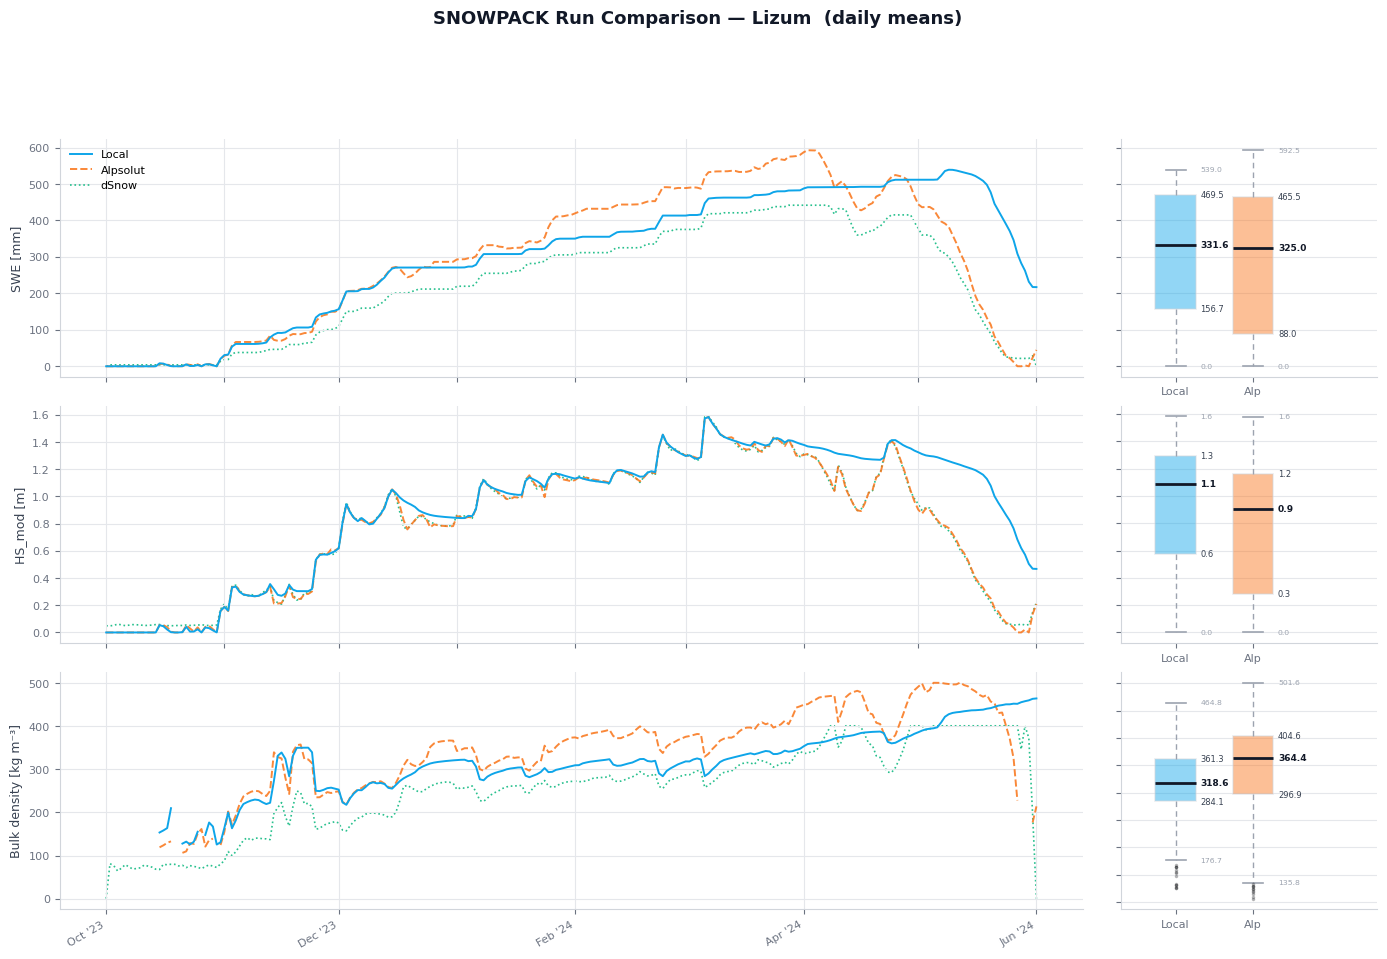

In [63]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

LOCAL_C, ALP_C = "#0EA5E9", "#F97316"

def _annotate_box(ax, series, x_pos):
    s = series.dropna()
    q1, med, q3 = float(s.quantile(0.25)), float(s.median()), float(s.quantile(0.75))
    iqr = q3 - q1
    lo  = float(s[s >= q1 - 1.5 * iqr].min())
    hi  = float(s[s <= q3 + 1.5 * iqr].max())
    for y, lbl, fs, fw, col in [
        (hi,  f"{hi:.1f}",  5.5, "normal", "#9CA3AF"),
        (q3,  f"{q3:.1f}",  6.0, "normal", "#374151"),
        (med, f"{med:.1f}", 6.5, "bold",   "#111827"),
        (q1,  f"{q1:.1f}",  6.0, "normal", "#374151"),
        (lo,  f"{lo:.1f}",  5.5, "normal", "#9CA3AF"),
    ]:
        ax.text(x_pos + 0.32, y, lbl, fontsize=fs, fontweight=fw,
                color=col, va="center", clip_on=False)

fig = plt.figure(figsize=(17, 10), facecolor="white")
fig.suptitle("SNOWPACK Run Comparison — Lizum  (daily means)",
             fontsize=13, fontweight="bold", color="#111827", y=1.01)
gs = fig.add_gridspec(3, 2, width_ratios=[4, 1], hspace=0.12, wspace=0.06)

vars_ = [
    ("SWE_loc",  "SWE_alp",  "SWE_dsnow", "SWE [mm]"),
    ("HS_loc",   "HS_alp",   "HS_meas" , "HS_mod [m]"),
    ("rho_loc",  "rho_alp", "rho_dsnow", "Bulk density [kg m⁻³]"),
]

for row, (loc_col, alp_col, third_col, ylabel) in enumerate(vars_):
    ax_ts  = fig.add_subplot(gs[row, 0])
    ax_box = fig.add_subplot(gs[row, 1])

    # Time series: local, Alpine, and the third column (e.g., measured)
    ax_ts.plot(check_df.index, check_df[loc_col],
               color=LOCAL_C, lw=1.4, label="Local", zorder=3)
    ax_ts.plot(check_df.index, check_df[alp_col],
               color=ALP_C, lw=1.4, ls="--", alpha=0.85, label="Alpsolut", zorder=2)
    ax_ts.plot(check_df.index, check_df[third_col],
               color="#10B981", lw=1.2, ls=":", alpha=0.9, label="dSnow", zorder=1)

    ax_ts.set_ylabel(ylabel)
    ax_ts.grid(True, zorder=0)
    if row == 0:
        ax_ts.legend(loc="upper left")
    if row < 2:
        ax_ts.tick_params(labelbottom=False)
    else:
        ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
        ax_ts.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=30, ha="right")

    # Boxplot: only Local and Alpine (measured data is often sparse/irregular)
    bp = ax_box.boxplot(
        [check_df[loc_col].dropna(), check_df[alp_col].dropna()],
        labels=["Local", "Alp"], patch_artist=True, widths=0.52,
        medianprops=dict(color="#111827", lw=2.0),
        whiskerprops=dict(color="#9CA3AF", lw=1.0, linestyle=(0, (4, 3))),
        capprops=dict(color="#9CA3AF", lw=1.2),
        boxprops=dict(linewidth=1.2, edgecolor="#D1D5DB"),
        flierprops=dict(marker=".", markersize=3, alpha=0.25,
                        markerfacecolor="#6B7280", linestyle="none"),
    )
    for patch, color in zip(bp["boxes"], [LOCAL_C, ALP_C]):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)

    _annotate_box(ax_box, check_df[loc_col], 1)
    _annotate_box(ax_box, check_df[alp_col], 2)

    ax_box.set_xlim(0.3, 3.6)
    ax_box.grid(True, axis="y")
    ax_box.tick_params(labelleft=False)

plt.tight_layout()
plt.show()

## 5. Difference Statistics (local − Alpsolut)

In [64]:
diff = pd.DataFrame({
    "ΔSWE [mm]":   check_df["SWE_loc"] - check_df["SWE_alp"],
    "ΔHS_mod [m]": check_df["HS_loc"]  - check_df["HS_alp"],
    "Δρ_bulk":     check_df["rho_loc"] - check_df["rho_alp"],
})
diff.describe().round(3)

,ΔSWE [mm],ΔHS_mod [m],Δρ_bulk
count,245.000,245.000,225.000
mean,7.913,0.112,-31.094
std,104.158,0.216,57.377
min,-101.638,-0.027,-109.411
25%,-70.705,0.000,-64.771
50%,-3.126,0.010,-40.699
75%,5.283,0.088,-7.457
max,365.185,0.848,343.092


## 6. Direct Comparison — Exact Overlapping Timestamps Only

5,851 shared timestamps


/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3081/3659733105.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3081/3659733105.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3081/3659733105.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_3081/3659733105.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results mig

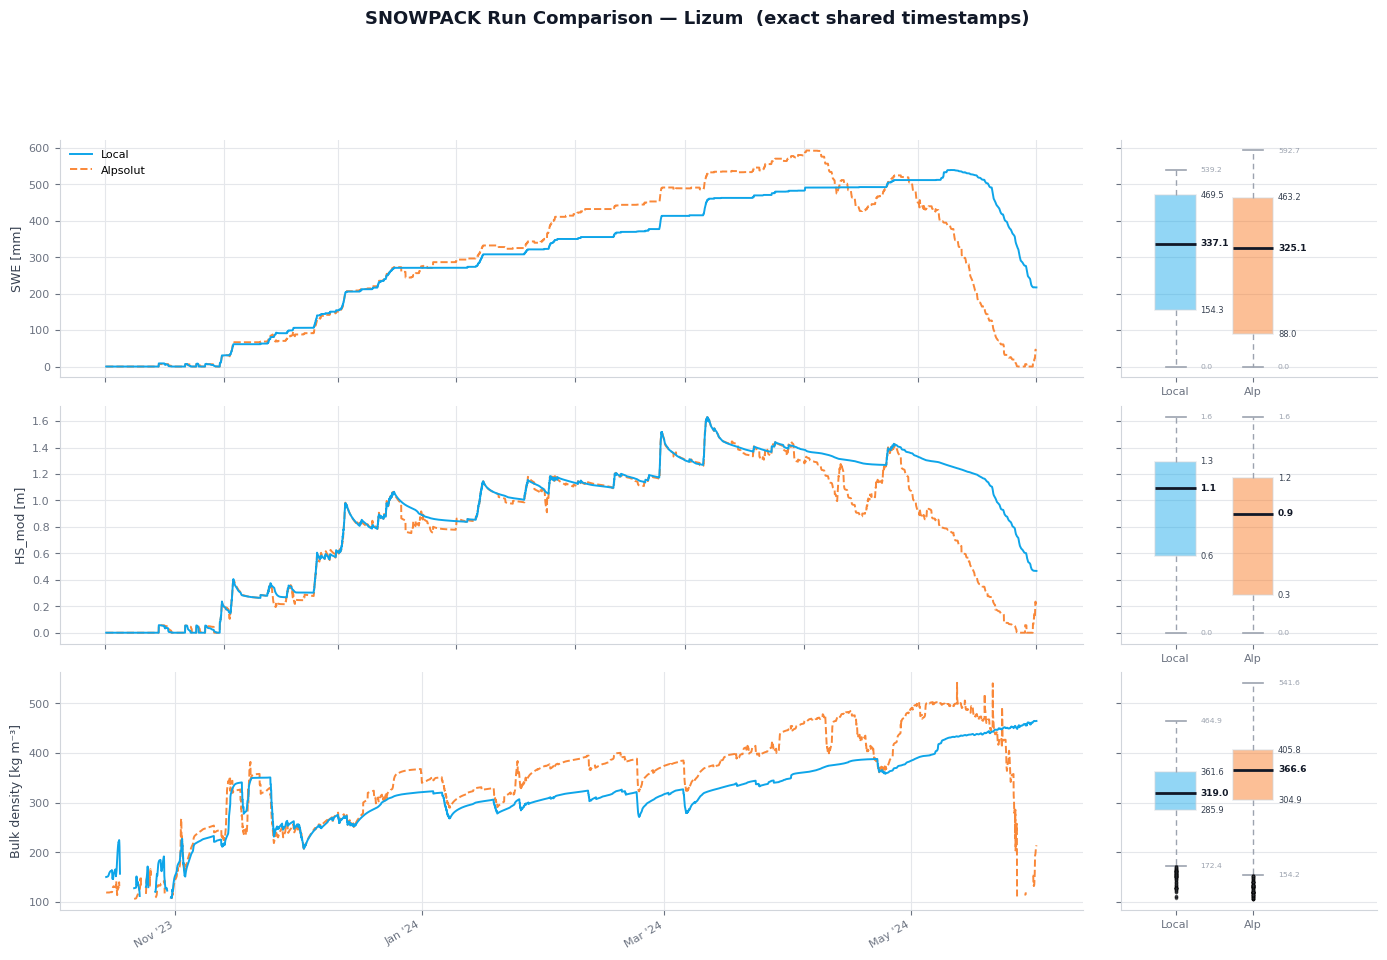

,SWE_loc,SWE_alp,HS_loc,HS_alp,rho_loc,rho_alp
count,5851.000,5851.000,5851.000,5851.000,5339.000,5260.000
mean,304.149,296.875,0.909,0.798,319.597,352.490
std,174.488,195.022,0.473,0.479,69.733,91.830
min,0.000,0.000,0.000,0.000,108.689,106.280
25%,154.318,87.979,0.580,0.285,285.898,304.918
50%,337.105,325.058,1.093,0.900,319.036,366.624
75%,469.465,463.243,1.294,1.166,361.612,405.792
max,539.197,592.721,1.629,1.633,464.867,541.623


In [65]:
LOCAL_C, ALP_C = "#0EA5E9", "#F97316"

def _annotate_box(ax, series, x_pos):
    s = series.dropna()
    q1, med, q3 = float(s.quantile(0.25)), float(s.median()), float(s.quantile(0.75))
    iqr = q3 - q1
    lo  = float(s[s >= q1 - 1.5 * iqr].min())
    hi  = float(s[s <= q3 + 1.5 * iqr].max())
    for y, lbl, fs, fw, col in [
        (hi,  f"{hi:.1f}",  5.5, "normal", "#9CA3AF"),
        (q3,  f"{q3:.1f}",  6.0, "normal", "#374151"),
        (med, f"{med:.1f}", 6.5, "bold",   "#111827"),
        (q1,  f"{q1:.1f}",  6.0, "normal", "#374151"),
        (lo,  f"{lo:.1f}",  5.5, "normal", "#9CA3AF"),
    ]:
        ax.text(x_pos + 0.32, y, lbl, fontsize=fs, fontweight=fw,
                color=col, va="center", clip_on=False)

shared_idx = df_local.index.intersection(df_alp.index)
print(f"{len(shared_idx):,} shared timestamps")

exact = pd.DataFrame(index=shared_idx)
exact["SWE_loc"]  = df_local.loc[shared_idx, "SWE"]
exact["SWE_alp"]  = df_alp.loc[shared_idx, "SWE"]
exact["HS_loc"]   = df_local.loc[shared_idx, "HS_mod"] / 100
exact["HS_alp"]   = df_alp.loc[shared_idx, "HS_mod"]
exact["rho_loc"]  = exact["SWE_loc"] / exact["HS_loc"]
exact["rho_alp"]  = exact["SWE_alp"] / exact["HS_alp"]

fig = plt.figure(figsize=(17, 10), facecolor="white")
fig.suptitle("SNOWPACK Run Comparison — Lizum  (exact shared timestamps)",
             fontsize=13, fontweight="bold", color="#111827", y=1.01)
gs = fig.add_gridspec(3, 2, width_ratios=[4, 1], hspace=0.12, wspace=0.06)

vars_ = [
    ("SWE_loc",  "SWE_alp",  "SWE [mm]"),
    ("HS_loc",   "HS_alp",   "HS_mod [m]"),
    ("rho_loc",  "rho_alp",  "Bulk density [kg m⁻³]"),
]

for row, (loc_col, alp_col, ylabel) in enumerate(vars_):
    ax_ts  = fig.add_subplot(gs[row, 0])
    ax_box = fig.add_subplot(gs[row, 1])

    ax_ts.plot(exact.index, exact[loc_col],
               color=LOCAL_C, lw=1.4, label="Local", zorder=3)
    ax_ts.plot(exact.index, exact[alp_col],
               color=ALP_C, lw=1.4, ls="--", alpha=0.85, label="Alpsolut", zorder=2)
    ax_ts.set_ylabel(ylabel)
    ax_ts.grid(True, zorder=0)
    if row == 0:
        ax_ts.legend(loc="upper left")
    if row < 2:
        ax_ts.tick_params(labelbottom=False)
    else:
        ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
        ax_ts.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=30, ha="right")

    bp = ax_box.boxplot(
        [exact[loc_col].dropna(), exact[alp_col].dropna()],
        labels=["Local", "Alp"], patch_artist=True, widths=0.52,
        medianprops=dict(color="#111827", lw=2.0),
        whiskerprops=dict(color="#9CA3AF", lw=1.0, linestyle=(0, (4, 3))),
        capprops=dict(color="#9CA3AF", lw=1.2),
        boxprops=dict(linewidth=1.2, edgecolor="#D1D5DB"),
        flierprops=dict(marker=".", markersize=3, alpha=0.25,
                        markerfacecolor="#6B7280", linestyle="none"),
    )
    for patch, color in zip(bp["boxes"], [LOCAL_C, ALP_C]):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    _annotate_box(ax_box, exact[loc_col], 1)
    _annotate_box(ax_box, exact[alp_col], 2)
    ax_box.set_xlim(0.3, 3.6)
    ax_box.grid(True, axis="y")
    ax_box.tick_params(labelleft=False)

plt.tight_layout()
plt.show()

exact.describe().round(3)

In [66]:
diff = pd.DataFrame({
    "ΔSWE [mm]":   exact["SWE_loc"] - exact["SWE_alp"],
    "ΔHS_mod [m]": exact["HS_loc"]  - exact["HS_alp"],
    "Δρ_bulk":     exact["rho_loc"] - exact["rho_alp"],
})
diff.describe().round(3)

,ΔSWE [mm],ΔHS_mod [m],Δρ_bulk
count,5851.000,5851.000,5237.000
mean,7.275,0.112,-35.326
std,103.772,0.216,49.212
min,-102.784,-0.046,-112.341
25%,-70.575,0.000,-64.953
50%,-5.383,0.010,-44.925
75%,5.372,0.085,-10.030
max,371.071,0.864,344.134
